# Student Employability: Regression and Clustering

Vortex Tech AI & ML Internship 2026 -- Week 3

This notebook has two independent parts: a regression model predicting `expected_salary_pkr` (a continuous target), and a K-Means clustering analysis grouping students by `cgpa` and `attendance_percentage`.

## Part 1: Regression

### 1. Import Libraries

Imports numpy, pandas, matplotlib, and seaborn. Scikit-learn pieces are imported later, right where each is first used.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### 2. Load the Cleaned Dataset

Loads pk_student_employability_cleaned.csv, the same cleaned dataset used in Week 1 and Week 2, and checks its shape and first rows.

In [2]:
df = pd.read_csv('pk_student_employability_cleaned.csv')
df.shape


(47839, 49)

In [3]:
df.head()


,student_id,age,gender,city,province,university_name,university_type,degree_program,specialization,current_semester,...,expected_salary_pkr,job_readiness_score,employability_status,preferred_career_path,likely_to_get_hired,remote_work_interest,daily_study_hours,internet_quality,device_type,social_media_usage_hours
0,PKSTU00001,21,Male,Lahore,Punjab,University of Peshawar,Public,Information Technology,Cloud IT,2,...,33000,100.0,Highly Employable,IT Manager,Yes,Neutral,3.8,Average,Smartphone Only,3.3
1,PKSTU00002,22,Female,Faisalabad,Punjab,COMSATS,Public,Information Technology,ERP Systems,3,...,76000,100.0,Highly Employable,Network Engineer,Yes,Slightly Interested,4.4,Average,Laptop,5.5
2,PKSTU00003,24,Female,Quetta,Balochistan,Air University,Public,Computer Science,Theory of Computation,3,...,50000,100.0,Highly Employable,Web Developer,Yes,Interested,7.5,Poor,Desktop,3.0
3,PKSTU00005,19,Female,Sargodha,Punjab,COMSATS,Public,Artificial Intelligence,Computer Vision,7,...,81000,88.8,Highly Employable,AI/ML Engineer,Yes,Interested,5.5,Excellent,Laptop,2.9
4,PKSTU00006,19,Male,Gilgit,GB,Hamdard University,Private,Artificial Intelligence,Deep Learning,4,...,100000,99.4,Highly Employable,AI/ML Engineer,Yes,Neutral,7.4,Poor,Laptop,6.9


### 3. Inspect the Regression Target

Shows descriptive statistics for expected_salary_pkr, giving a reference point (mean and standard deviation) for judging model error later.

In [4]:
df['expected_salary_pkr'].describe()


count     47839.000000
mean      75952.800017
std       26714.785835
min       25000.000000
25%       57000.000000
50%       73000.000000
75%       92000.000000
max      228000.000000
Name: expected_salary_pkr, dtype: float64

### 4. Select Feature Columns (X) and Target (y)

Drops student_id (identifier), expected_salary_pkr (the target itself), and likely_to_get_hired and employability_status (both leakage risks, since they are outcome labels partly determined by salary and related factors). job_readiness_score is kept as a feature: it correlates with the target at only about 0.28, a real but moderate relationship rather than a near-restatement of the answer.

In [5]:
drop_cols = ['student_id', 'likely_to_get_hired', 'employability_status', 'expected_salary_pkr']
X = df.drop(columns=drop_cols)
y = df['expected_salary_pkr']

X.shape


(47839, 45)

In [6]:
y.shape


(47839,)

### 5. Encode Categorical Features

Converts all remaining text/category columns into numeric columns using one-hot encoding. Expect a large jump in column count, since several columns (university_name, specialization, etc.) have many unique values.

In [7]:
X = pd.get_dummies(X, drop_first=True)
X.shape


(47839, 238)

### 6. Train-Test Split

Splits X and y into 80% training and 20% testing data. No stratify argument this time, since the target is continuous, not categorical.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape


(38271, 238)

In [9]:
X_test.shape


(9568, 238)

### 7. Train a Linear Regression Model

Fits a LinearRegression model on the training data and generates salary predictions for the test set.

In [10]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)


### 8. Evaluate the Linear Regression Model

Calculates RMSE (prediction error in the same units as salary, PKR) and R-squared (proportion of variation in salary explained by the model).

In [11]:
from sklearn.metrics import mean_squared_error, r2_score

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print(f"Linear Regression RMSE: {lr_rmse:,.2f}")
print(f"Linear Regression R2:   {lr_r2:.4f}")


Linear Regression RMSE: 19,847.34
Linear Regression R2:   0.4538


### 9. Train and Evaluate a Random Forest Regressor

Trains a second model, RandomForestRegressor, on the same data for comparison against Linear Regression.

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print(f"Random Forest RMSE: {rf_rmse:,.2f}")
print(f"Random Forest R2:   {rf_r2:.4f}")


Random Forest RMSE: 20,335.68
Random Forest R2:   0.4265


### 10. Compare Both Regression Models

Puts both models' RMSE and R2 into a single table for direct comparison.

In [13]:
regression_comparison = pd.DataFrame({
    'Linear Regression': [lr_rmse, lr_r2],
    'Random Forest': [rf_rmse, rf_r2]
}, index=['RMSE', 'R2'])

regression_comparison.round(4)


,Linear Regression,Random Forest
RMSE,19847.3381,20335.6763
R2,0.4538,0.4265


### 11. Interpretation -- Regression

Linear Regression was used as the primary model since it is the standard starting point for a continuous target. Random Forest was trained for comparison, and interestingly performed slightly worse (higher RMSE, lower R2) rather than better. This is a genuinely useful finding, not a failure: with over 200 columns after one-hot encoding several high-cardinality categorical columns, a more flexible model like Random Forest has more opportunity to fit noise in the training data rather than the true underlying pattern, while Linear Regression's simplicity worked in its favor here.

In plain terms, an RMSE of roughly 19,800 to 20,300 PKR means predictions are typically off by about that much in either direction, smaller than the target's overall standard deviation of about 26,715 PKR, so the model is doing meaningfully better than just guessing the average salary for every student. An R2 of roughly 0.43 to 0.45 means the model explains under half of what actually drives expected salary, so other unmeasured factors clearly matter too.

Next steps worth trying: dropping some of the very high-cardinality categorical columns that may be adding more noise than signal, trying a regularized linear model such as Ridge or Lasso, or gathering features not present in this dataset, such as actual work experience or specific technical assessment scores, that might explain more of the remaining variation in salary expectations.

## Part 2: Clustering

### 12. Select and Inspect Clustering Columns

Selects cgpa and attendance_percentage, two continuous columns on different natural scales, making this a good demonstration of why scaling matters before clustering.

In [14]:
cluster_data = df[['cgpa', 'attendance_percentage']]
cluster_data.describe()


,cgpa,attendance_percentage
count,47839.000000,47839.000000
mean,2.909652,77.644710
std,0.519722,13.288522
min,1.500000,30.000000
25%,2.560000,68.600000
50%,2.920000,78.000000
75%,3.270000,87.400000
max,4.000000,100.000000


### 13. Scale the Data

Standardizes both columns to mean 0 and standard deviation 1, so KMeans does not treat attendance_percentage as more important than cgpa purely because its raw numbers are bigger.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)


### 14. Run the Elbow Method

Fits KMeans for k = 1 through 10, records inertia for each, and plots k against inertia to visually identify where adding more clusters stops meaningfully helping.

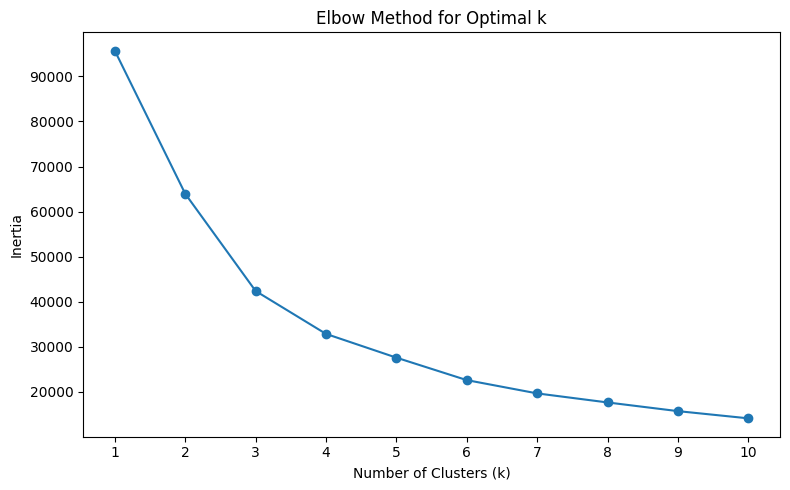

In [16]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()


### 15. Choice of k

Inertia drops from about 63,962 at k=2 to about 42,398 at k=3, a decrease of roughly 21,564. From k=3 to k=4, it drops from about 42,398 to about 32,883, a decrease of roughly 9,515, under half the previous drop. This is where the curve visibly starts flattening, so **k=4** is chosen: enough clusters to capture real structure in the data without adding clusters past the point of meaningful return.

### 16. Fit the Final KMeans Model

Fits KMeans with the chosen k=4 and assigns every student to a cluster, stored as a new column.

In [17]:
chosen_k = 4

kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_data)

df['cluster'] = cluster_labels
df['cluster'].value_counts()


cluster
2    13371
3    11843
1    11322
0    11303
Name: count, dtype: int64

### 17. Visualize the Clusters

Plots every student by their actual (unscaled) cgpa and attendance_percentage, colored by cluster assignment.

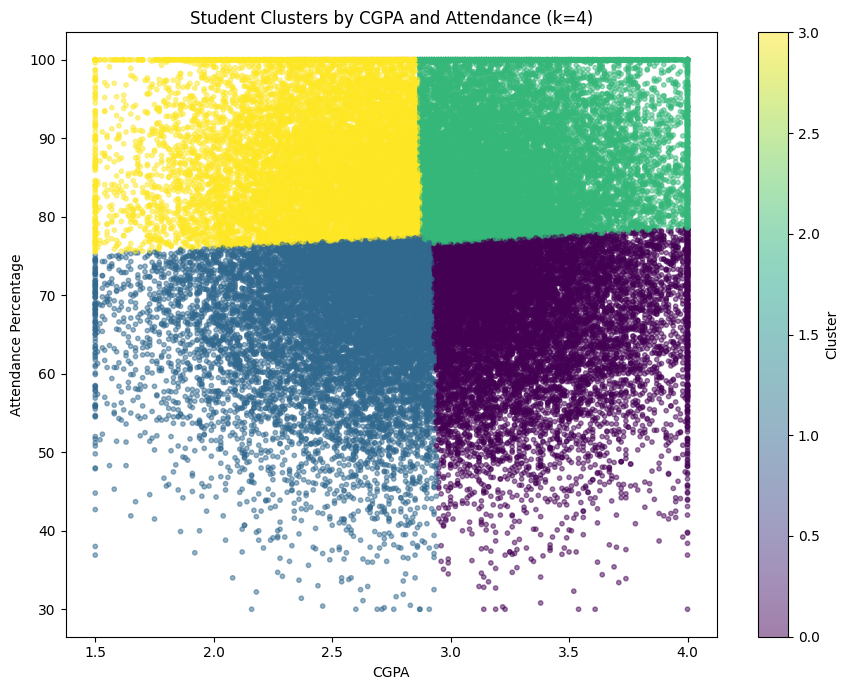

In [18]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    df['cgpa'], df['attendance_percentage'],
    c=df['cluster'], cmap='viridis', alpha=0.5, s=10
)
plt.xlabel('CGPA')
plt.ylabel('Attendance Percentage')
plt.title(f'Student Clusters by CGPA and Attendance (k={chosen_k})')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()


### 18. Profile Each Cluster

Averages cgpa and attendance_percentage within each cluster to turn the abstract group numbers into a readable real-world profile.

In [19]:
df.groupby('cluster')[['cgpa', 'attendance_percentage']].mean()


,cgpa,attendance_percentage
cluster,,
0,3.347537,66.403397
1,2.504604,66.062895
2,3.287412,88.040969
3,2.452461,87.708165


### 19. Interpretation -- Clustering

k=4 was chosen based on the elbow method numbers in step 15, where the rate of inertia reduction dropped by more than half between k=3 and k=4, indicating diminishing returns beyond that point.

The four clusters, based on their average CGPA and attendance, can be described as:
- **High performer, lower attendance**: strong CGPA (around 3.35), but attends less consistently (around 66%)
- **At-risk**: lower CGPA (around 2.50) and lower attendance (around 66%) -- the group most likely to benefit from proactive academic support
- **High performer, engaged**: strong CGPA (around 3.29) and high attendance (around 88%) -- the most consistently successful group
- **Present but struggling**: high attendance (around 88%) but lower CGPA (around 2.45) -- attending class but not translating that into academic performance, which may need a different kind of support than the at-risk group

Practically, this grouping could help a university advising team prioritize outreach: the at-risk cluster is the clearest candidate for early intervention, while the present-but-struggling cluster suggests a need to investigate study habits or classroom engagement rather than attendance itself.